In [6]:
import pandas as pd
import numpy as np
import sys 
import os


In [ ]:
import pickle
import os

SIMILARITY_METHOD = None
INVARIANT_DISTANCE_METHOD = "cid"
WINDOW_SIZE = 7
STEP_SIZE = 1
SIMILARITY_THRESHOLD = 0.8

# The invariances generate "dynamic_invariances_output_" while similarities generate "dynamic_graphs_output_"
if INVARIANT_DISTANCE_METHOD is not None and SIMILARITY_METHOD is None:
    base_name = f'dynamic_invariances_output_{INVARIANT_DISTANCE_METHOD}_{SIMILARITY_THRESHOLD}_Window{WINDOW_SIZE}_Step{STEP_SIZE}'
    pkl_path = f'../GraphAnalysis/DynamicGraphPkls/{INVARIANT_DISTANCE_METHOD}/{base_name}.pkl'
    plot_dir = f'../GraphAnalysis/DynamicGraphPkls/{INVARIANT_DISTANCE_METHOD}/{base_name}_plots'
else:
    base_name = f'dynamic_graphs_output_{SIMILARITY_METHOD}_{SIMILARITY_THRESHOLD}_Window{WINDOW_SIZE}_Step{STEP_SIZE}'
    pkl_path = f'../GraphAnalysis/DynamicGraphPkls/{SIMILARITY_METHOD}/{base_name}.pkl'
    plot_dir = f'../GraphAnalysis/DynamicGraphPkls/{SIMILARITY_METHOD}/{base_name}_plots'

os.makedirs(plot_dir, exist_ok=True)

print(f"A carregar grafos e features pré-computados de {pkl_path}...")
with open(pkl_path, 'rb') as f:
    graph_data = pickle.load(f)

# Extrair todas as variáveis de volta para o ambiente do notebook
graphs = graph_data['graphs']
sim_dfs = graph_data.get('sim_dfs', graph_data.get('dist_dfs')) # Handles backward compat between similarities and distances
df_pivots = graph_data['df_pivots']
window_info = graph_data['window_info']
dynamic_graph_features = graph_data.get('dynamic_graph_features') # Might be None

print(f"Sucesso! Foram carregadas as informações de {len(graphs)} janelas temporais.")
print(f"Os gráficos serão guardados em: {plot_dir}")

A carregar grafos e features pré-computados de ../GraphAnalysis/DynamicGraphPkls/cid/dynamic_invariances_output_cid_0.8_Window7_Step1.pkl...
Sucesso! Foram carregadas as informações de 603 janelas temporais.


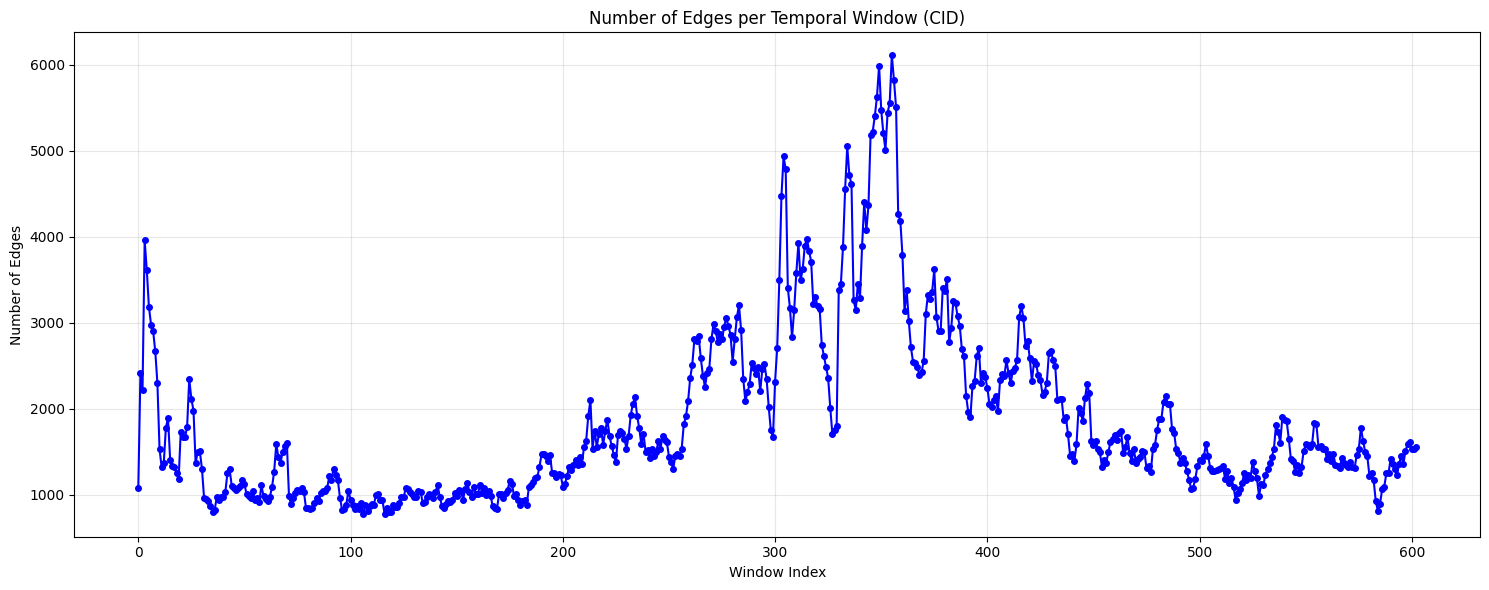

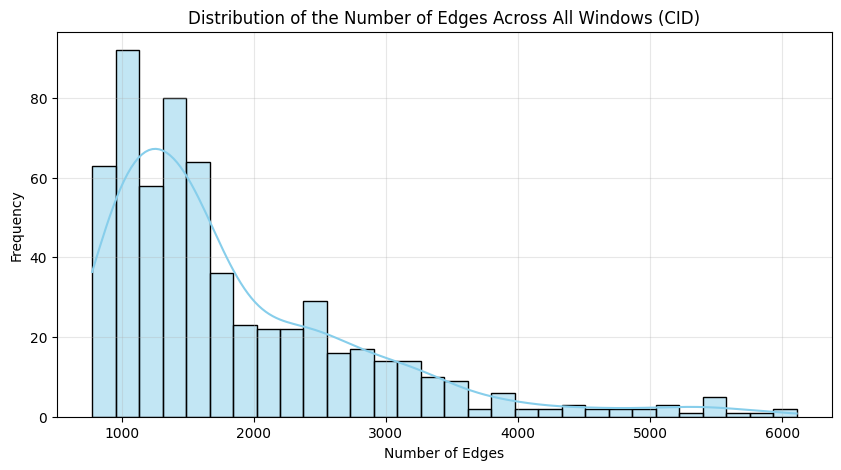

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Extract the number of edges for each graph in the sequence
edges_per_window = [g.number_of_edges() for g in graphs]

# 1. Line plot to see the evolution of edge counts over time windows
plt.figure(figsize=(15, 6))
plt.plot(range(len(edges_per_window)), edges_per_window, marker='o', linestyle='-', color='b', markersize=4)
method_name = INVARIANT_DISTANCE_METHOD.upper() if INVARIANT_DISTANCE_METHOD else SIMILARITY_METHOD.upper()
plt.title(f"Number of Edges per Temporal Window ({method_name})")
plt.xlabel("Window Index")
plt.ylabel("Number of Edges")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, 'edges_per_window.png'), dpi=300, bbox_inches='tight')
plt.show()

# 2. Histogram / KDE to see the overall distribution of edge counts
plt.figure(figsize=(10, 5))
sns.histplot(edges_per_window, bins=30, kde=True, color='skyblue')
plt.title(f"Distribution of the Number of Edges Across All Windows ({method_name})")
plt.xlabel("Number of Edges")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(plot_dir, 'edges_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

MemoryError: Unable to allocate 4.56 GiB for an array with shape (612426483,) and data type int64

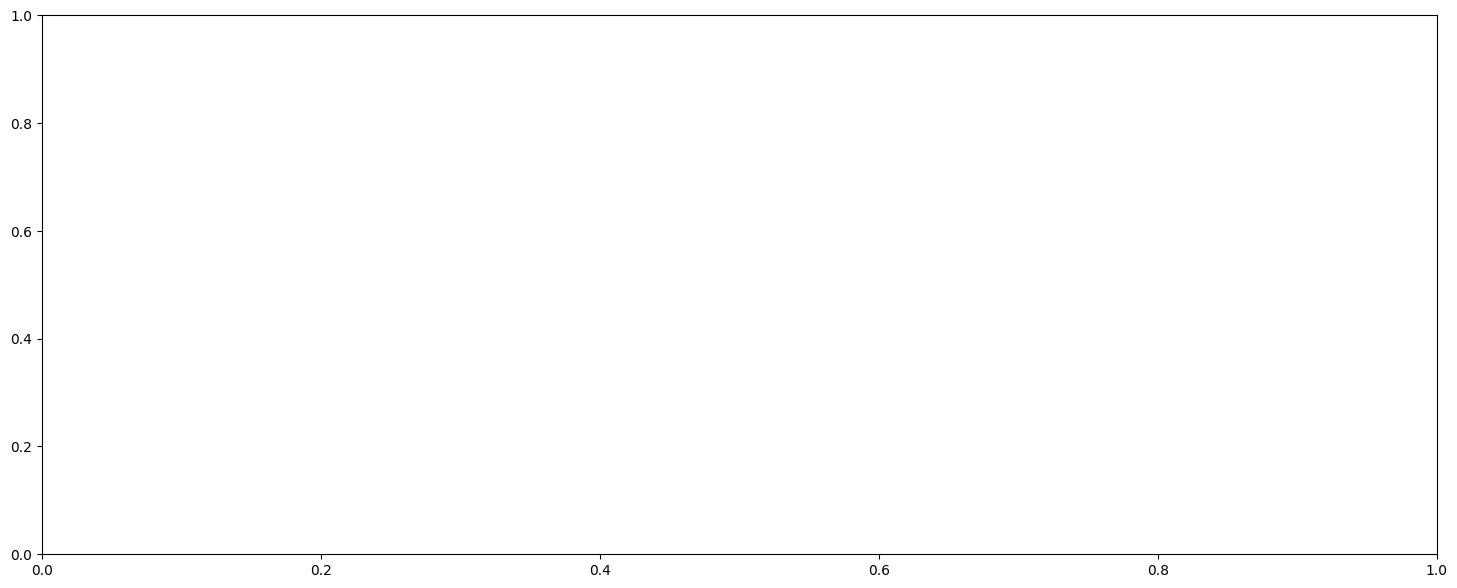

In [21]:
'''
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Extract lower triangle values from the similarity/distance matrices
# to avoid duplicating edges and omitting the self-loops (diagonal)
all_values_by_window = []

# Uses sim_dfs which was unified above to collect matrices uniformly
for w_idx, adj_matrix in enumerate(sim_dfs):
    # Depending on input (NumPy arrays or Pandas DataFrame)
    if isinstance(adj_matrix, pd.DataFrame):
        vals = adj_matrix.values
    else:
        vals = adj_matrix
        
    # Get lower triangle indices (excluding diagonal)
    mask = np.tril(np.ones(vals.shape), k=-1).astype(bool)
    lower_tri_vals = vals[mask]
    
    # Store for plotting
    df_temp = pd.DataFrame({
        'Window': [w_idx] * len(lower_tri_vals),
        'Value': lower_tri_vals
    })
    all_values_by_window.append(df_temp)

# Combine into a single large dataframe for Seaborn
df_plot = pd.concat(all_values_by_window, ignore_index=True)

# Generate Boxplot
plt.figure(figsize=(18, 7))
sns.boxplot(data=df_plot, x='Window', y='Value', color='skyblue', fliersize=1)

method_name = INVARIANT_DISTANCE_METHOD.upper() if INVARIANT_DISTANCE_METHOD else SIMILARITY_METHOD.upper()
metric_type = "Distance" if INVARIANT_DISTANCE_METHOD else "Similarity"

plt.title(f"Distribution of {method_name} {metric_type}s Across Time Windows")
plt.xlabel("Window Index")
plt.ylabel(f"{method_name} Value")

# Rotate x-axis labels if there are too many windows
num_windows = len(sim_dfs)
if num_windows > 30:
    plt.xticks(ticks=range(0, num_windows, 5), labels=range(0, num_windows, 5), rotation=45)
else:
    plt.xticks(rotation=45)
    
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
'''

Window with most edges: 355 (6109 edges)


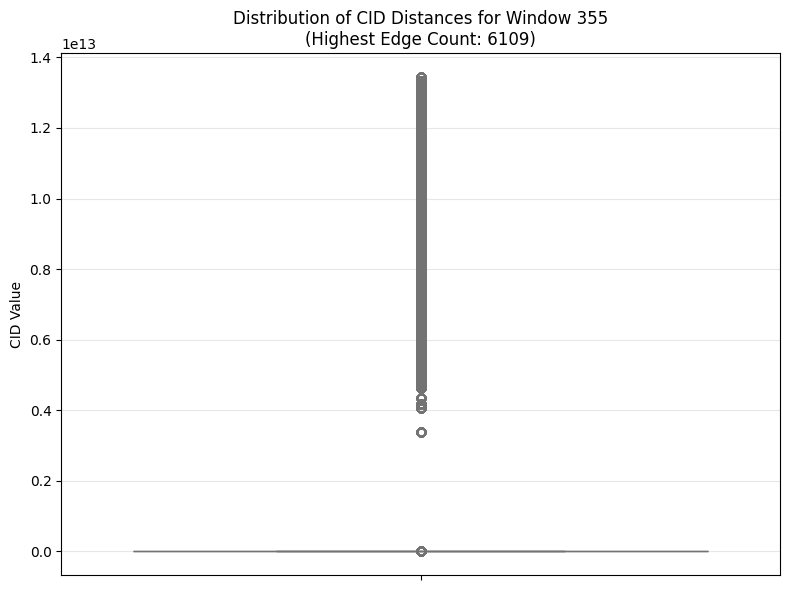

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

# Find the window with the maximum number of edges
edges_per_window = [g.number_of_edges() for g in graphs]
max_edges_window_idx = np.argmax(edges_per_window)
max_edges_count = edges_per_window[max_edges_window_idx]

print(f"Window with most edges: {max_edges_window_idx} ({max_edges_count} edges)")

# Get the matrix for this specific window
adj_matrix_max = sim_dfs[max_edges_window_idx]

if isinstance(adj_matrix_max, pd.DataFrame):
    vals_max = adj_matrix_max.values
else:
    vals_max = adj_matrix_max

# Get lower triangle indices (excluding diagonal) to avoid self-loops and duplicates
mask_max = np.tril(np.ones(vals_max.shape), k=-1).astype(bool)
lower_tri_vals_max = vals_max[mask_max]

# Generate Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=lower_tri_vals_max, color='lightgreen')

method_name = INVARIANT_DISTANCE_METHOD.upper() if INVARIANT_DISTANCE_METHOD else SIMILARITY_METHOD.upper()
metric_type = "Distance" if INVARIANT_DISTANCE_METHOD else "Similarity"

plt.title(f"Distribution of {method_name} {metric_type}s for Window {max_edges_window_idx}\n(Highest Edge Count: {max_edges_count})")
plt.ylabel(f"{method_name} Value")

plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, f'distribution_window_{max_edges_window_idx}.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import networkx as nx
from collections import Counter
import sys
import os

sys.path.append(os.path.abspath('../..'))
from DynamicSimilarities.plot import save_graph_plot

# 1. Count how many times each edge appears across all temporal graphs
edge_counts = Counter()
total_graphs = len(graphs)

for g in graphs:
    # Ensure edge tuples are sorted so (A, B) and (B, A) are counted as the same edge
    for u, v in g.edges():
        edge = tuple(sorted((str(u), str(v))))
        edge_counts[edge] += 1

# 2. Create a DataFrame to analyze the persistence of each relationship
persistent_edges = pd.DataFrame(
    [(u, v, count, count / total_graphs * 100) for (u, v), count in edge_counts.items()],
    columns=['Node1', 'Node2', 'Occurrences', 'Persistence (%)']
)

# Sort by persistence (descending) to find the most stable relationships
persistent_edges = persistent_edges.sort_values(by='Persistence (%)', ascending=False).reset_index(drop=True)

print(f"Analysis over {total_graphs} temporal graphs.")
print(f"Total unique edges that appeared at least once: {len(persistent_edges)}")
print("\nTop 20 most stable product relationships:")
display(persistent_edges.head(20))

# 3. Optional: Create a "Consensus Graph" with edges present in at least X% of the time (e.g., 50%)
THRESHOLD_PERCENT = 50.0
stable_graph = nx.Graph()

# Add only the edges that meet the threshold
stable_edges = persistent_edges[persistent_edges['Persistence (%)'] >= THRESHOLD_PERCENT]
for _, row in stable_edges.iterrows():
    stable_graph.add_edge(row['Node1'], row['Node2'], weight=row['Persistence (%)'])

print(f"\nCreated a Consensus Graph with {stable_graph.number_of_edges()} edges (Persistence >= {THRESHOLD_PERCENT}%)")

# Optional: Save the consensus graph plot
save_graph_plot(
    G=stable_graph, 
    strategy_name=f"Consensus_Graph_Persistence_{SIMILARITY_METHOD or INVARIANT_DISTANCE_METHOD}_{int(THRESHOLD_PERCENT)}",
    output_folder=plot_dir,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE
)

Analysis over 603 temporal graphs.
Total unique edges that appeared at least once: 395939

Top 20 most stable product relationships:


,Node1,Node2,Occurrences,Persistence (%)
0,132423,59990,123,20.398010
1,13339,161359,114,18.905473
2,132423,1869,113,18.739635
3,161359,962210,112,18.573798
4,132423,30665,108,17.910448
5,13339,30665,104,17.247098
6,132423,661641,102,16.915423
7,132423,13339,98,16.252073
8,1869,661641,98,16.252073
9,13339,57457,98,16.252073



Created a Consensus Graph with 0 edges (Persistence >= 50.0%)
Graph automatically saved to: consensus_graph_plots\consensus_graph_persistence_none_50_0_nodes.png


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

# 1. Collect histories for degree, betweenness, and eigenvector centrality
node_degree_history = {}
node_betweenness_history = {}
node_eigenvector_history = {}

print("Calculating degree and centrality metrics across all windows. This may take a moment...")
for w_idx, g in enumerate(graphs):
    # Calculate centralities for the current window
    # Weight handling: if your edges have weights, networkx uses them differently.
    # For betweenness, nx expects "distance" or cost, so we often ignore it or invert it. Let's ignore it for basic structural betweenness.
    # For eigenvector, weight represents connection strength, which is good.
    betweenness = nx.betweenness_centrality(g, weight=None)
    
    try:
        # Eigenvector centrality can sometimes fail to converge, so we use a try-except block
        eigenvector = nx.eigenvector_centrality(g, max_iter=500, weight='weight')
    except nx.PowerIterationFailedConvergence:
        eigenvector = {n: 0 for n in g.nodes()} # Fallback if it fails

    for node in g.nodes():
        # Initialize histories if node not seen yet
        if node not in node_degree_history:
            node_degree_history[node] = []
            node_betweenness_history[node] = []
            node_eigenvector_history[node] = []
            
        # Append metrics
        node_degree_history[node].append(g.degree[node])
        node_betweenness_history[node].append(betweenness.get(node, 0))
        node_eigenvector_history[node].append(eigenvector.get(node, 0))

# 2. Compute statistics across time for all metrics
node_stats = []
for node in node_degree_history.keys():
    degrees = node_degree_history[node]
    betweenness_vals = node_betweenness_history[node]
    eigenvector_vals = node_eigenvector_history[node]
    
    node_stats.append({
        'Node': node,
        # Degree stats
        'Mean_Degree': np.mean(degrees),
        'Median_Degree': np.median(degrees),
        'Std_Degree': np.std(degrees),
        'Max_Degree': np.max(degrees),
        'Zero_Degree_Windows': sum(1 for d in degrees if d == 0),
        
        # Centrality stats (using Mean as the primary aggregator)
        'Mean_Betweenness': np.mean(betweenness_vals),
        'Mean_Eigenvector': np.mean(eigenvector_vals)
    })

df_node_stats = pd.DataFrame(node_stats)

# 3. Create a combined Stability Score.
# We want nodes that are consistently connected (high mean degree, low std dev).
# We also might want nodes that are influential in their local clusters (Eigenvector)
# or act as bridges between different product types (Betweenness).
df_node_stats['Degree_Stability'] = df_node_stats['Mean_Degree'] / (df_node_stats['Std_Degree'] + 1e-5)

# Example: Sort by Eigenvector Centrality to find the most "influential" nodes in the network
df_node_stats = df_node_stats.sort_values(by='Mean_Eigenvector', ascending=False).reset_index(drop=True)

print("Calculation complete!")
display(df_node_stats.head())


Calculating degree and centrality metrics across all windows. This may take a moment...
Calculation complete!


,Node,Mean_Degree,Median_Degree,Std_Degree,Max_Degree,Zero_Degree_Windows,Mean_Betweenness,Mean_Eigenvector,Degree_Stability
0,911753,4.296849,3.0,4.105545,39,27,0.002575,0.020673,1.046594
1,907969,4.398010,3.0,4.141462,39,34,0.002570,0.019972,1.061944
2,213625,3.611940,3.0,3.372701,31,64,0.002012,0.014248,1.070931
3,110187,3.331675,2.0,3.817057,40,82,0.001452,0.013929,0.872836
4,26008,3.728027,3.0,4.204435,35,56,0.001642,0.012935,0.886687


In [ ]:
df_node_stats.to_csv(f'node_stats_{SIMILARITY_METHOD}_Window{WINDOW_SIZE}_Step{STEP_SIZE}.csv', index=False)

In [ ]:

well_connected_nodes = df_node_stats.sort_values(by="Max_Degree", ascending=True)

print(f"Found {len(well_connected_nodes)} nodes that meet the criteria.")
print("\nTop 20 nodes for Node2Vec/LSTM testing:")
display(well_connected_nodes.head(20))

# Save the list of good candidate nodes for later use
candidate_nodes = well_connected_nodes['Node'].tolist()

Found 1427 nodes that meet the criteria.

Top 20 nodes for Node2Vec/LSTM testing:


,Node,Mean_Degree,Median_Degree,Std_Degree,Max_Degree,Zero_Degree_Windows,Mean_Betweenness,Mean_Eigenvector,Degree_Stability
1284,11118,2.132670,2.0,1.786900,8,115,0.001053,0.001007,1.193496
1387,535948,1.699834,1.0,1.730935,8,176,0.000586,0.000495,0.982027
1414,606429,1.449420,1.0,1.566231,8,204,0.000517,0.000232,0.925413
1378,235439,1.470978,1.0,1.613707,8,205,0.000554,0.000553,0.911547
1384,41718,1.512438,1.0,1.516442,8,178,0.000456,0.000513,0.997353
1382,48096,1.285240,1.0,1.555464,9,233,0.000300,0.000520,0.826270
917,945964,1.883914,1.0,1.924734,9,157,0.000650,0.002231,0.978787
1376,106109,1.590381,1.0,1.646054,9,186,0.000592,0.000563,0.966172
1227,233678,1.677852,1.0,1.764750,9,188,0.000683,0.001227,0.950754
1413,155524,1.522388,1.0,1.619967,9,189,0.000464,0.000233,0.939759


In [ ]:
lowest_max_degree = df_node_stats['Max_Degree'].min()


In [ ]:
'''
import networkx as nx
from networkx.algorithms.community import louvain_communities
from collections import defaultdict

# 1. Detect communities in each individual window using Louvain
window_communities = []

print("Detecting communities in each time window...")
for idx, g in enumerate(graphs):
    # Louvain returns a list of sets, where each set is a community of nodes
    try:
        # If your edges have weights, Louvain can use them to find better clusters
        comms = louvain_communities(g, weight='weight') 
    except:
        # Fallback if weight causes an issue
        comms = louvain_communities(g)
    
    window_communities.append(comms)

# 2. Track "co-occurrence" of nodes in the same community across time
# We will build a matrix counting how many times node A and node B ended up in the SAME cluster.
node_list = list(graphs[0].nodes()) # Assuming all graphs have the same nodes
co_occurrence_counts = defaultdict(int)

total_windows = len(window_communities)

for comms in window_communities:
    for community in comms:
        # For every pair of nodes in the same community, increment their co-occurrence score
        nodes_in_comm = list(community)
        for i in range(len(nodes_in_comm)):
            for j in range(i + 1, len(nodes_in_comm)):
                u, v = nodes_in_comm[i], nodes_in_comm[j]
                # Ensure consistent ordering so (A,B) and (B,A) map to the same key
                pair = tuple(sorted([str(u), str(v)]))
                co_occurrence_counts[pair] += 1

# 3. Filter for pairs that are clustered together in at least X% of the windows
STABLE_CLUSTER_THRESHOLD = 0.50 # e.g., clustered together 50% of the time combined
min_co_occurrences = total_windows * STABLE_CLUSTER_THRESHOLD

stable_pairs = {pair: count for pair, count in co_occurrence_counts.items() if count >= min_co_occurrences}

print(f"\nFound {len(stable_pairs)} product pairs that belong to the SAME cluster in at least {STABLE_CLUSTER_THRESHOLD*100}% of the windows.")

# 4. Build a "Stable Community Graph" to extract the final robust clusters
stable_cluster_graph = nx.Graph()
for (u, v), count in stable_pairs.items():
    stable_cluster_graph.add_edge(u, v, weight=count)

# Extract connected components from this stable graph. 
# These components represent your stable, long-lasting clusters.
stable_components = list(nx.connected_components(stable_cluster_graph))
stable_components.sort(key=len, reverse=True) # Sort by size

print(f"\nExtracted {len(stable_components)} stable clusters over time.")
for i, comp in enumerate(stable_components[:5]): # Print top 5 largest stable clusters
    print(f"Stable Cluster {i+1} (Size {len(comp)}): {list(comp)[:10]}...")

    '''